# Visualizing uncertainty on linear regression predictions

As always, it's good to calculate and represent how uncertain we are on the predictions we get from linear regression. We'll go through visualizing two types of uncertainty on our predictions: 

* a **confidence interval** of where we can be confident that the mean output lies and
* a **prediction interval** where we can be confident that individual output observations are.

## Setup
To start, we'll construct the same linear regression model predicting food truck profit from population size.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

In [2]:
profits = pd.read_csv('https://raw.githubusercontent.com/girishkuniyal/Predict-Profit-for-food-truck/refs/heads/master/ex1data1.txt',
                    header=None,
                    names=['population', 'profit'])
profits.info()
profits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  97 non-null     float64
 1   profit      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


Let's fit a linear regression model predicting the `profit` column from the `population` column.

In [3]:
model = smf.ols(formula = 'profit ~ population', data = profits).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 profit   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     223.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.02e-26
Time:                        15:41:02   Log-Likelihood:                -243.95
No. Observations:                  97   AIC:                             491.9
Df Residuals:                      95   BIC:                             497.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.8958      0.719     -5.415      0.000      -5.324      -2.467
population     1.1930      0.080     14.961      0.000       1.035       1.351
==============================================================================
Omnibus:                       39.986   Durbin-Watson:                   0.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              108.142
Skew:                           1.455   Prob(JB):                     3.29e-24
Kurtosis:                       7.276   Cond. No.                         21.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Make predictions from the model and get confidence intervals on those predictions

Now we'll create a prediction visualization grid by constructing a range of input values to pass to the model.

In [4]:
viz_grid = pd.DataFrame({'population': np.linspace(profits.population.min()-0.1,
                                                   profits.population.max()+0.1,
                                                   num=101)})
viz_grid

,population
0,4.926900
1,5.100661
2,5.274422
3,5.448183
4,5.621944
...,...
96,21.607956
97,21.781717
98,21.955478
99,22.129239


To get predictions **with a confidence interval**, we'll run two `statsmodels` functions: first the `get_prediction()` function to make predictions and then the `summary_frame()` function to get a Pandas dataframe with information on those predictions (including confidence intervals).

In [5]:
pred_summary = model.get_prediction(viz_grid).summary_frame()
pred_summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,1.982177,0.400893,1.186304,2.778049,-4.073054,8.037408
1,2.189479,0.392126,1.411011,2.967947,-3.863489,8.242447
2,2.396782,0.383659,1.635123,3.158441,-3.654047,8.447611
3,2.604085,0.375512,1.858598,3.349571,-3.444730,8.652899
4,2.811387,0.367708,2.081395,3.541380,-3.235537,8.858312
...,...,...,...,...,...,...
96,21.883238,1.115488,19.668714,24.097761,15.485072,28.281403
97,22.090540,1.128816,19.849558,24.331523,15.683169,28.497912
98,22.297843,1.142156,20.030377,24.565309,15.881161,28.714525
99,22.505146,1.155508,20.211172,24.799120,16.079049,28.931243


Unlike the plain `predict()` function we used earlier, the summary gives us some great additional information on the predictions:
* **mean**: the prediction, which if you remember, is actually an estimate of the mean output value you would get if you observed the output at that specific input value multiple times.
* **mean_se**: your best friend, the standard error of the mean
* **mean_ci_lower**: the lower bound on the 95% confidence interval for the estimate of the mean output prediction. This will be approximately 2 * **mean_se** lower than **mean**.
* **mean_ci_upper**: the upper bound on the 95% confidence interval for the estimate of the mean output prediction
* **obs_ci_lower**: the lower bound on the "prediction interval". We'll get into this later in this notebook!
* **obs_ci_upper**: the upper bound on the "prediction interval"

## Visualize predictions with confidence intervals

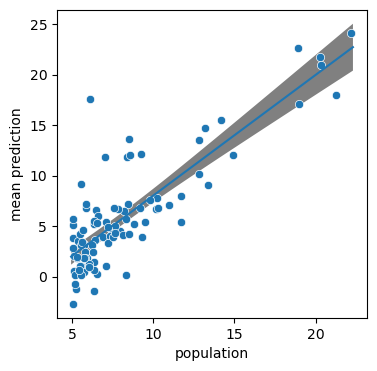

In [8]:
fig, ax = plt.subplots(figsize=(4,4))

# Line plot of linear regression predictions
sns.lineplot(x=viz_grid["population"], y=pred_summary["mean"], ax=ax )

# Ribbon for confidence interval
ax.fill_between(viz_grid["population"], pred_summary["mean_ci_lower"], pred_summary["mean_ci_upper"], facecolor="grey")

# Scatterplot of training data
sns.scatterplot(data=profits, x="population", y="profit", ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()

## Visualize predictions with confidence intervals and prediction intervals

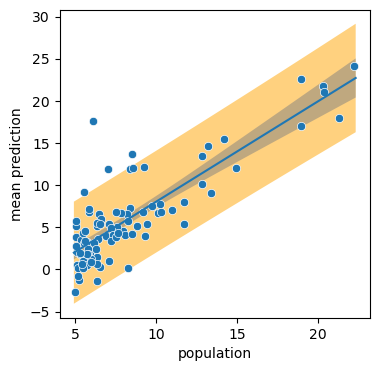

In [9]:
fig, ax = plt.subplots(figsize=(4,4))

# Line plot of linear regression predictions
sns.lineplot(x=viz_grid["population"], y=pred_summary["mean"], ax=ax )

# Ribbon for prediction interval
ax.fill_between(viz_grid["population"], pred_summary["obs_ci_lower"], pred_summary["obs_ci_upper"], facecolor="orange", alpha=0.5)

# Ribbon for confidence interval
ax.fill_between(viz_grid["population"], pred_summary["mean_ci_lower"], pred_summary["mean_ci_upper"], facecolor="grey", alpha=0.5)

# Scatterplot of training data
sns.scatterplot(data=profits, x="population", y="profit", ax=ax)

# Set the y-axis label
ax.set_ylabel("mean prediction")

plt.show()